<a href="https://colab.research.google.com/github/hwangho-kim/Transformer_Fewshot_PdM/blob/main/Production_FDC_Pipeline_260325_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[System] Using device: cpu

Phase 1: Loading data from CSV and Applying Interpolation Alignment...
-> Resampling all variable-length traces to target length (50 steps)...
Data ready! Pre-train: 800, Few-shot: 20 (Anomalies: 3), Test: 180

Phase 2: Foundation Model Pre-training (Unsupervised)...
-> Found existing model weights: factory_data/foundation_model_aligned.pth
Phase 3: Enhancing Anomaly Detection via Few-Shot Labels...
-> [Before Few-Shot] Evaluating Baseline Anomaly Indices...
-> [Fix] Freezing Autoencoder to preserve 'Expected Trace'...
-> Training Diagnostic Head (Neural Network for Anomaly Scoring)...
-> Diagnostic Head Training completed.

-> [After Few-Shot] Evaluating Enhanced Anomaly Indices...

📊 [Few-Shot 성능 강화 비교: 이상 탐지 능력 변화 리포트]
 - 강화 전 이상 웨이퍼 탐지수 : 3건
 - 강화 후 이상 웨이퍼 탐지수 : 3건

Phase 4: Plotting Anomaly Detection Control Charts...


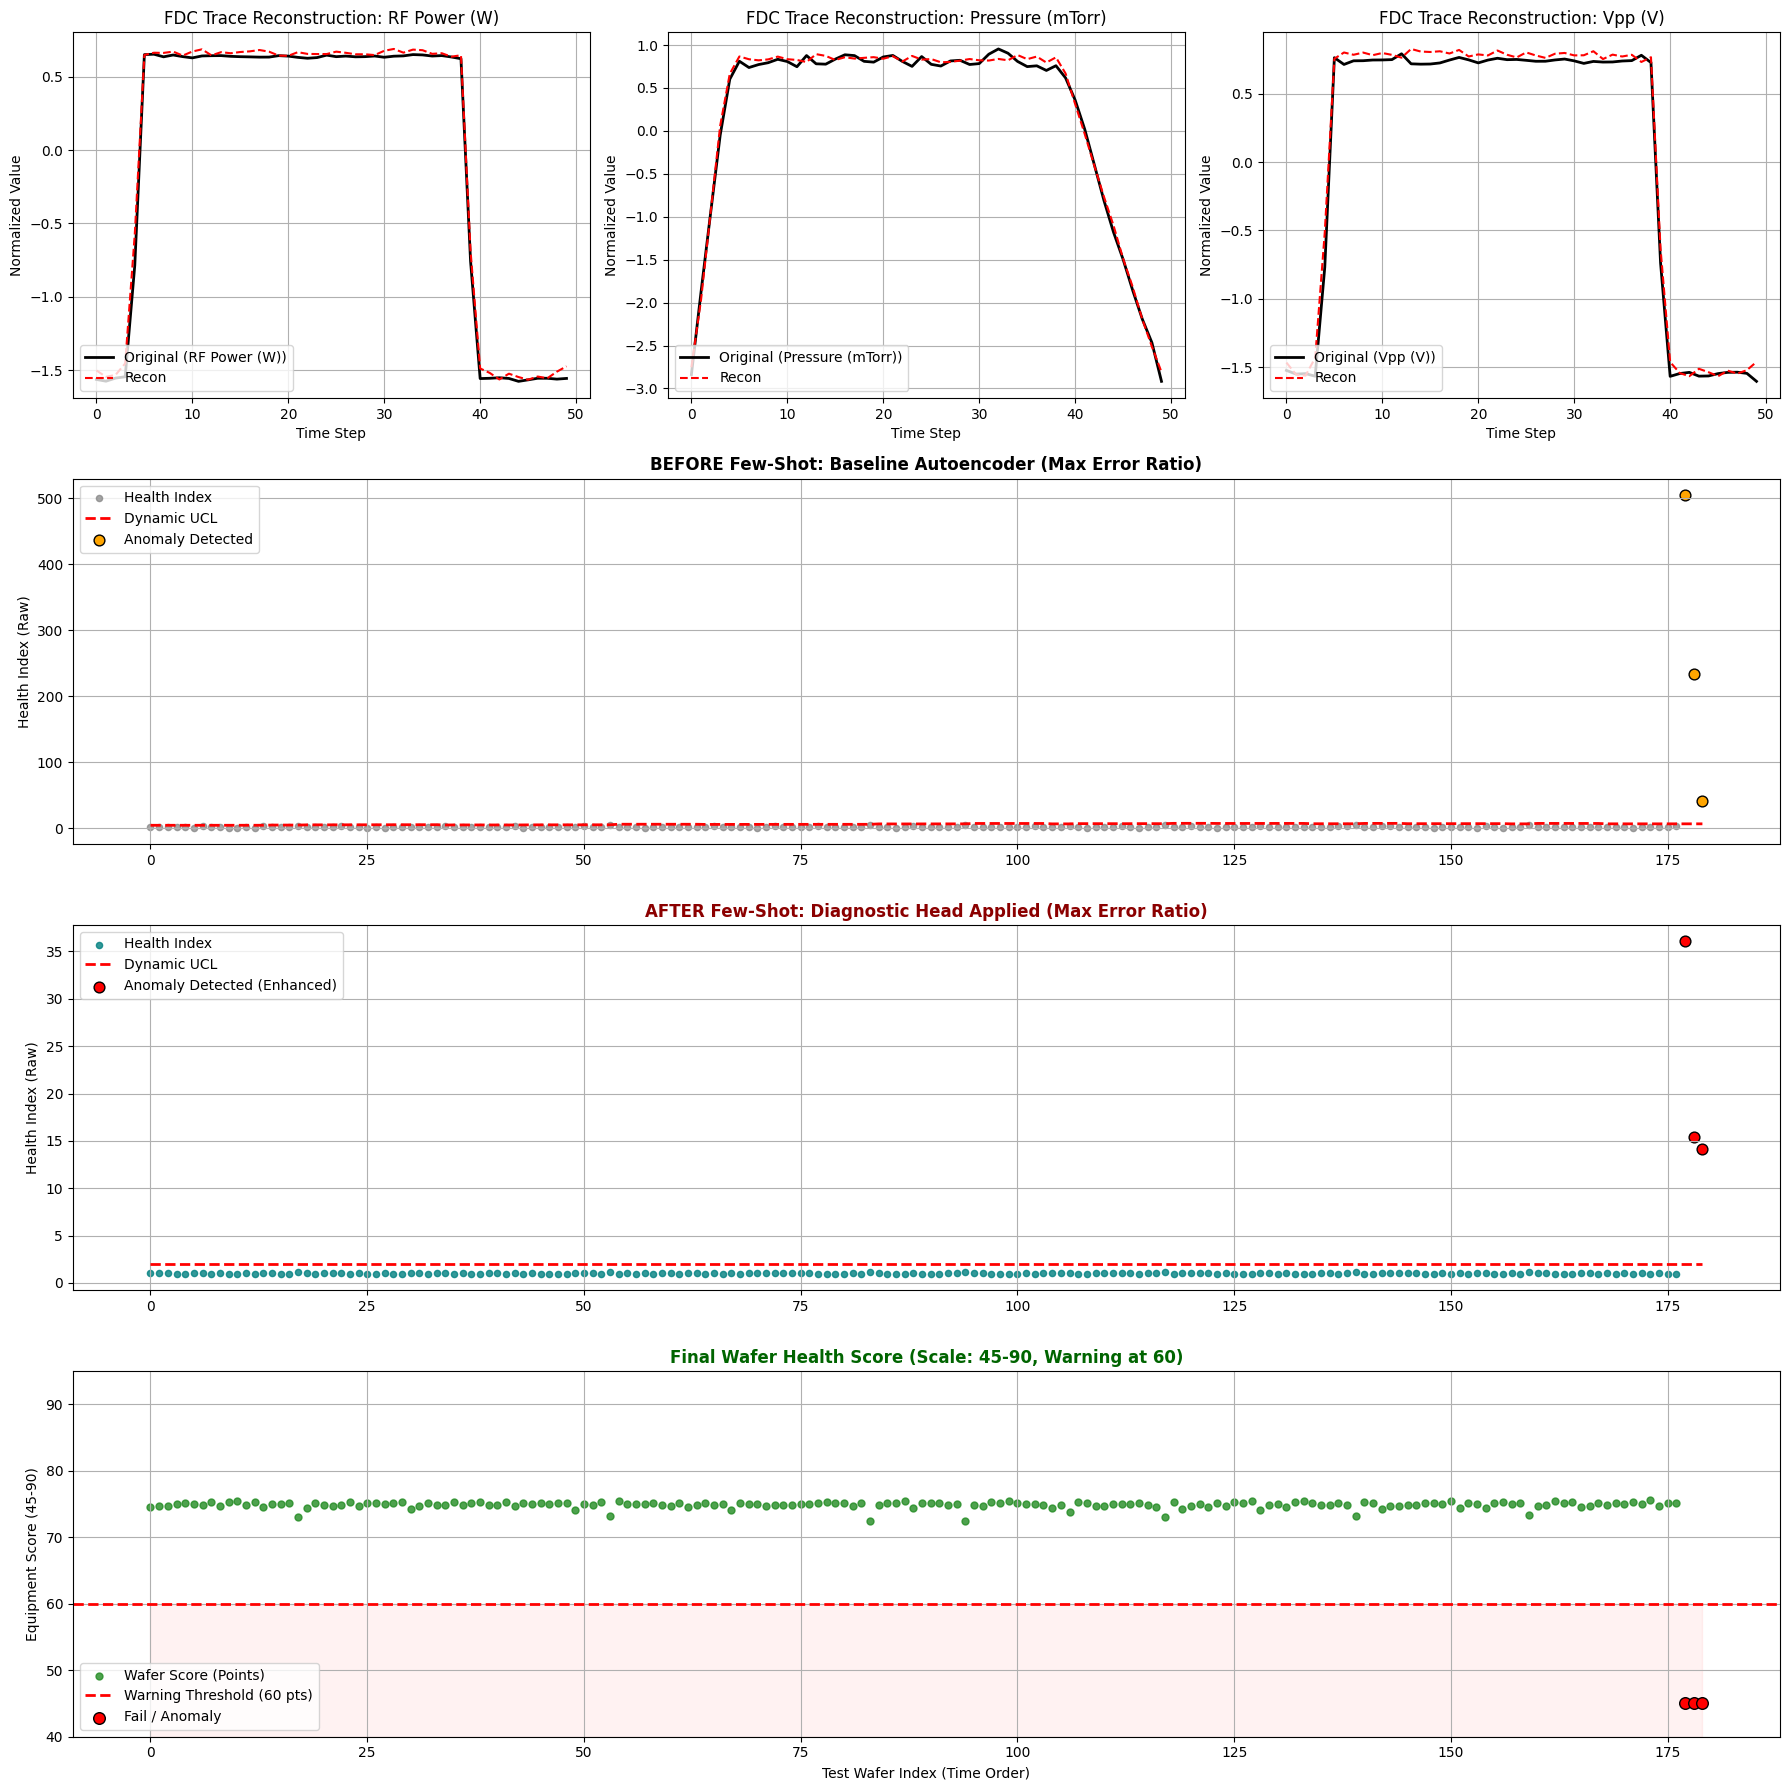

-> 100점 환산 스코어가 포함된 진단 결과 CSV 저장 완료: fdc_outputs/05_phase4_fdc_test_results.csv

Phase 5: XAI Root Cause Analysis


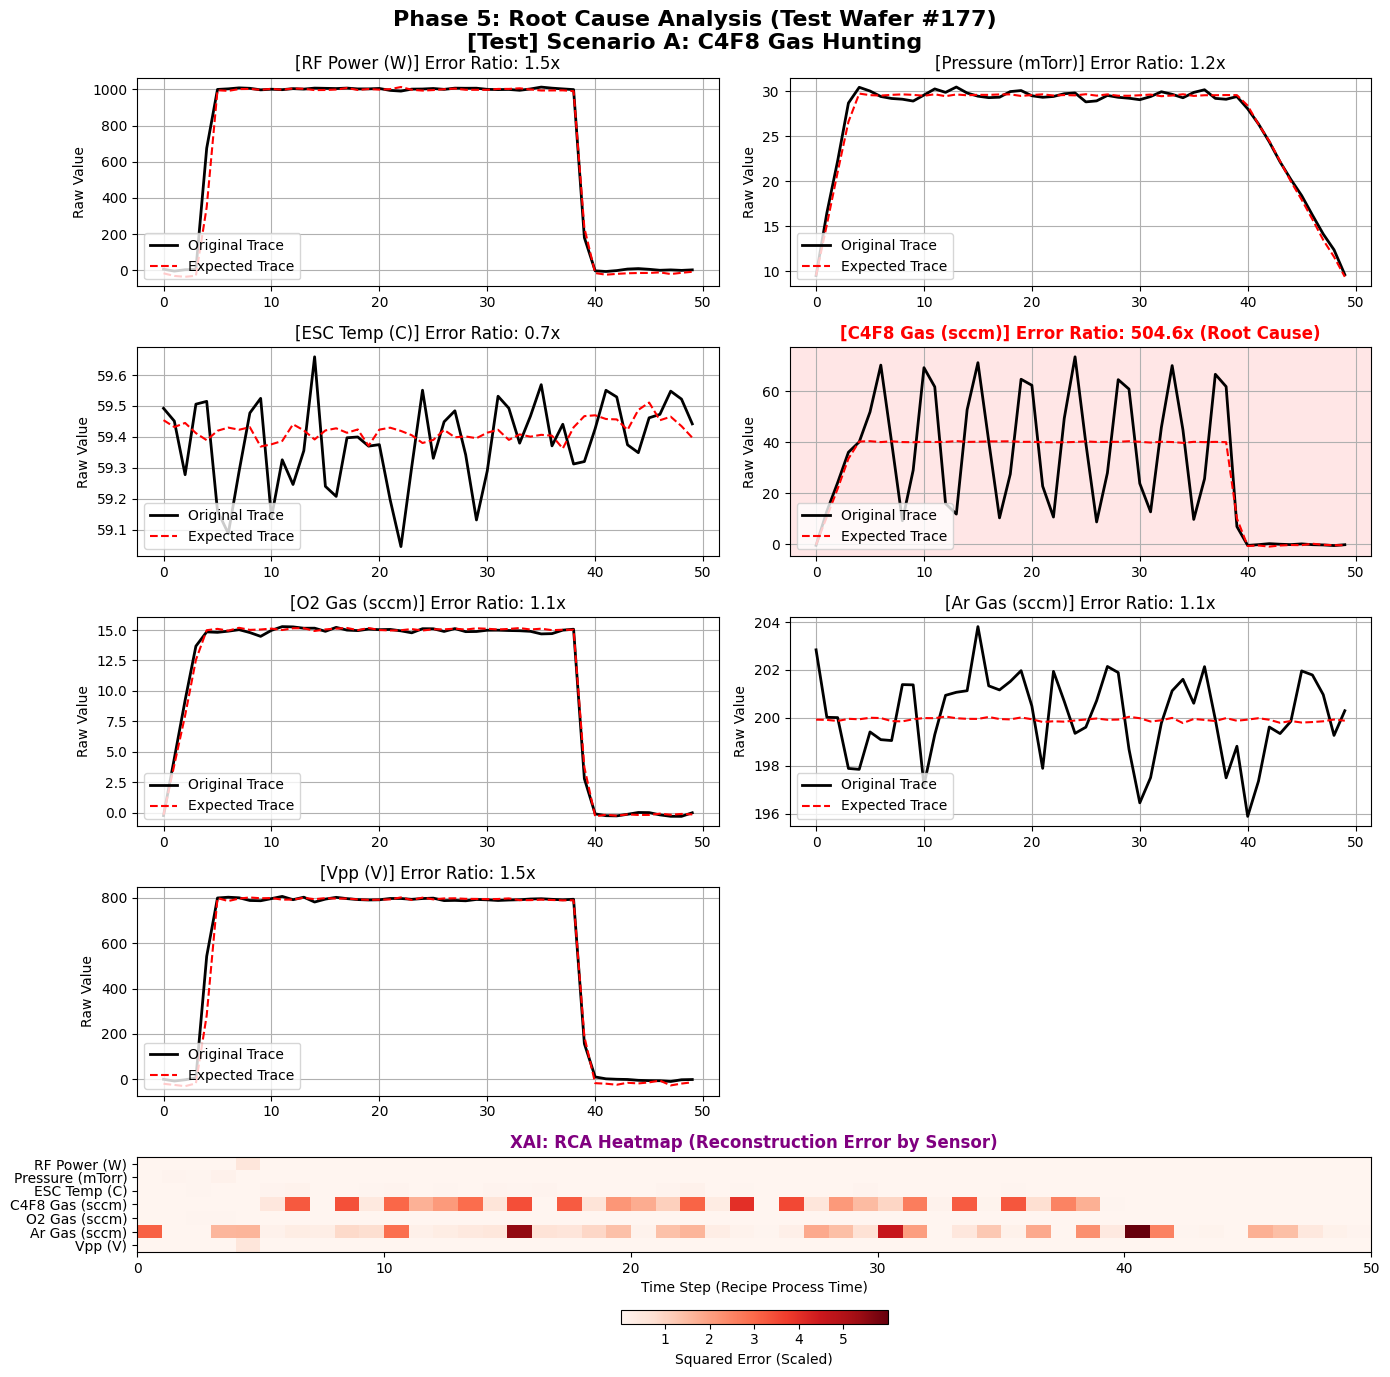


📑 [자동 진단 리포트] Test Wafer #177 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 A: C4F8 Gas 유량 헌팅
🚨 문제 원인 센서: C4F8 Gas (sccm)
      * C4F8 Gas (sccm): 평소 정상 대비 오차가 504.6배 폭증함

⏱️ 주요 이상 의심 시점 (RCA Heatmap 기반 에러 극대점):
   -> 전체 50 스텝 중 '15번째 스텝' 부근 (메인 식각(플라즈마 On) 구간에서)에서 실제 값과 예측 값의 괴리가 가장 컸습니다.



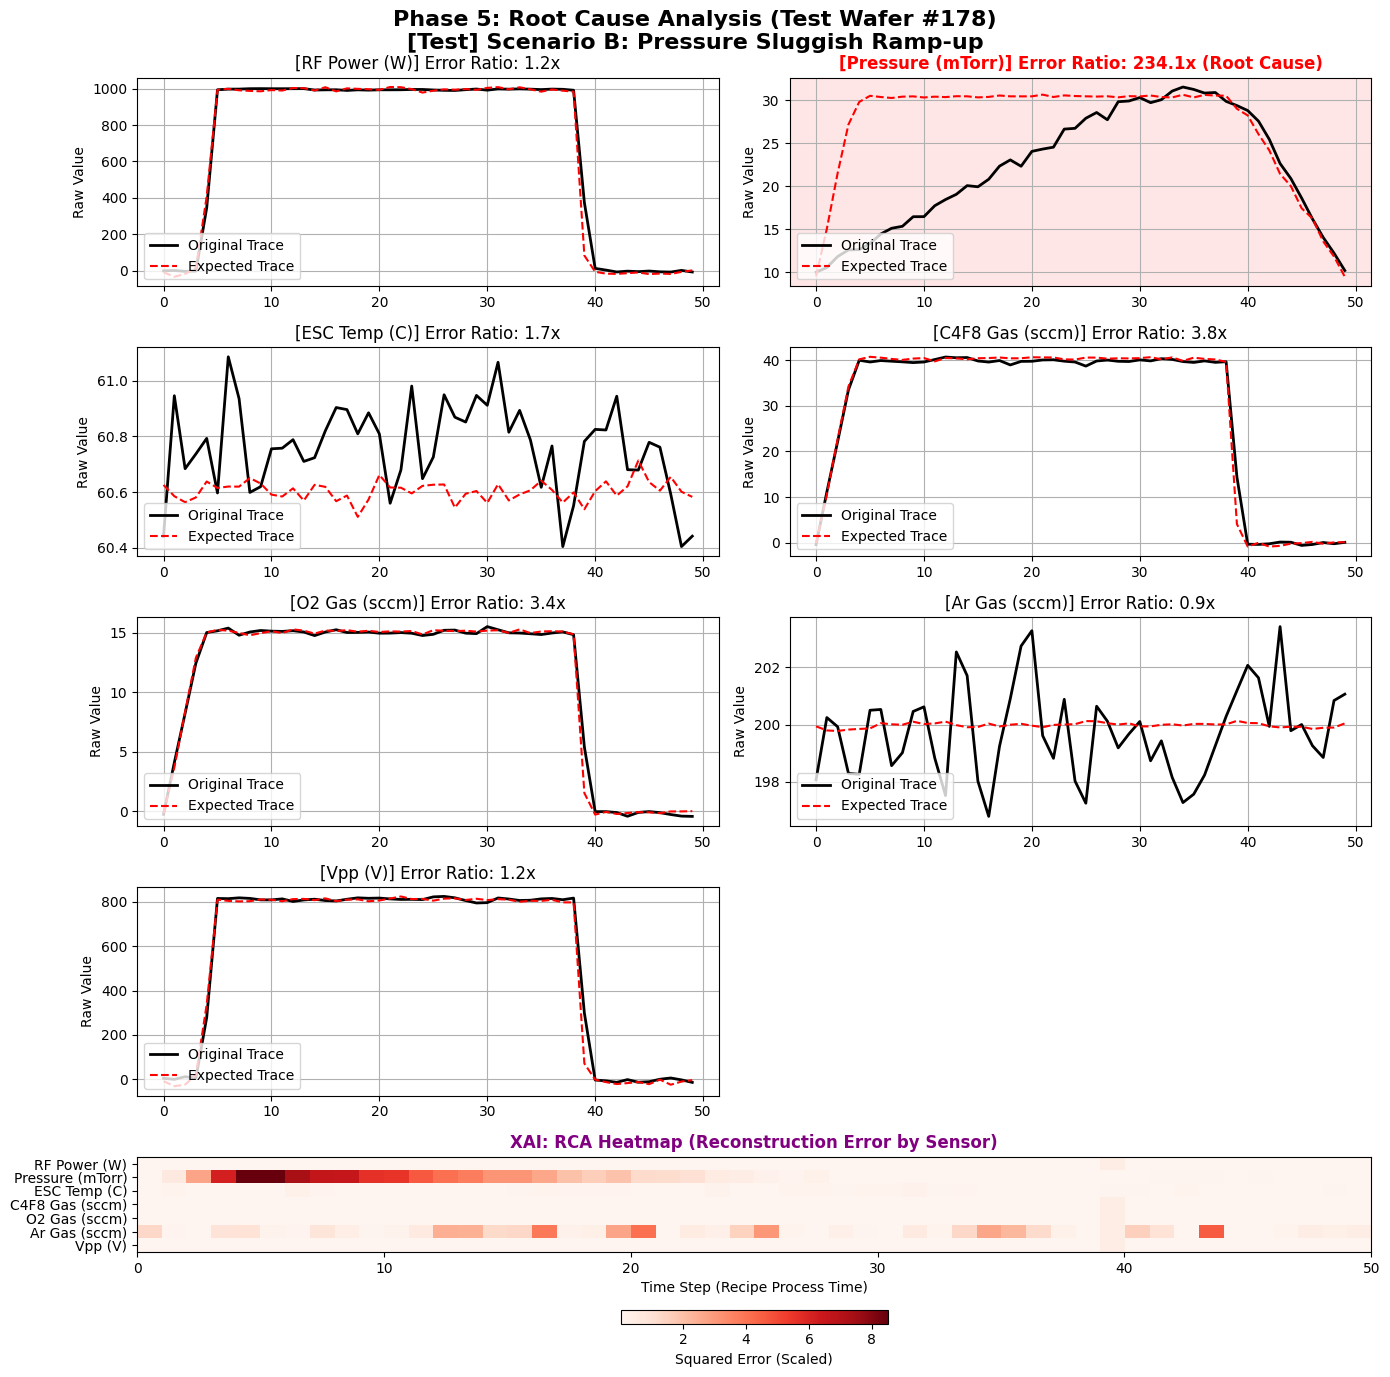


📑 [자동 진단 리포트] Test Wafer #178 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 B: Pressure 초기 도달 지연
🚨 문제 원인 센서: Pressure (mTorr)
      * Pressure (mTorr): 평소 정상 대비 오차가 234.1배 폭증함

⏱️ 주요 이상 의심 시점 (RCA Heatmap 기반 에러 극대점):
   -> 전체 50 스텝 중 '4번째 스텝' 부근 (가스 안정화(초기 램프업) 구간에서)에서 실제 값과 예측 값의 괴리가 가장 컸습니다.



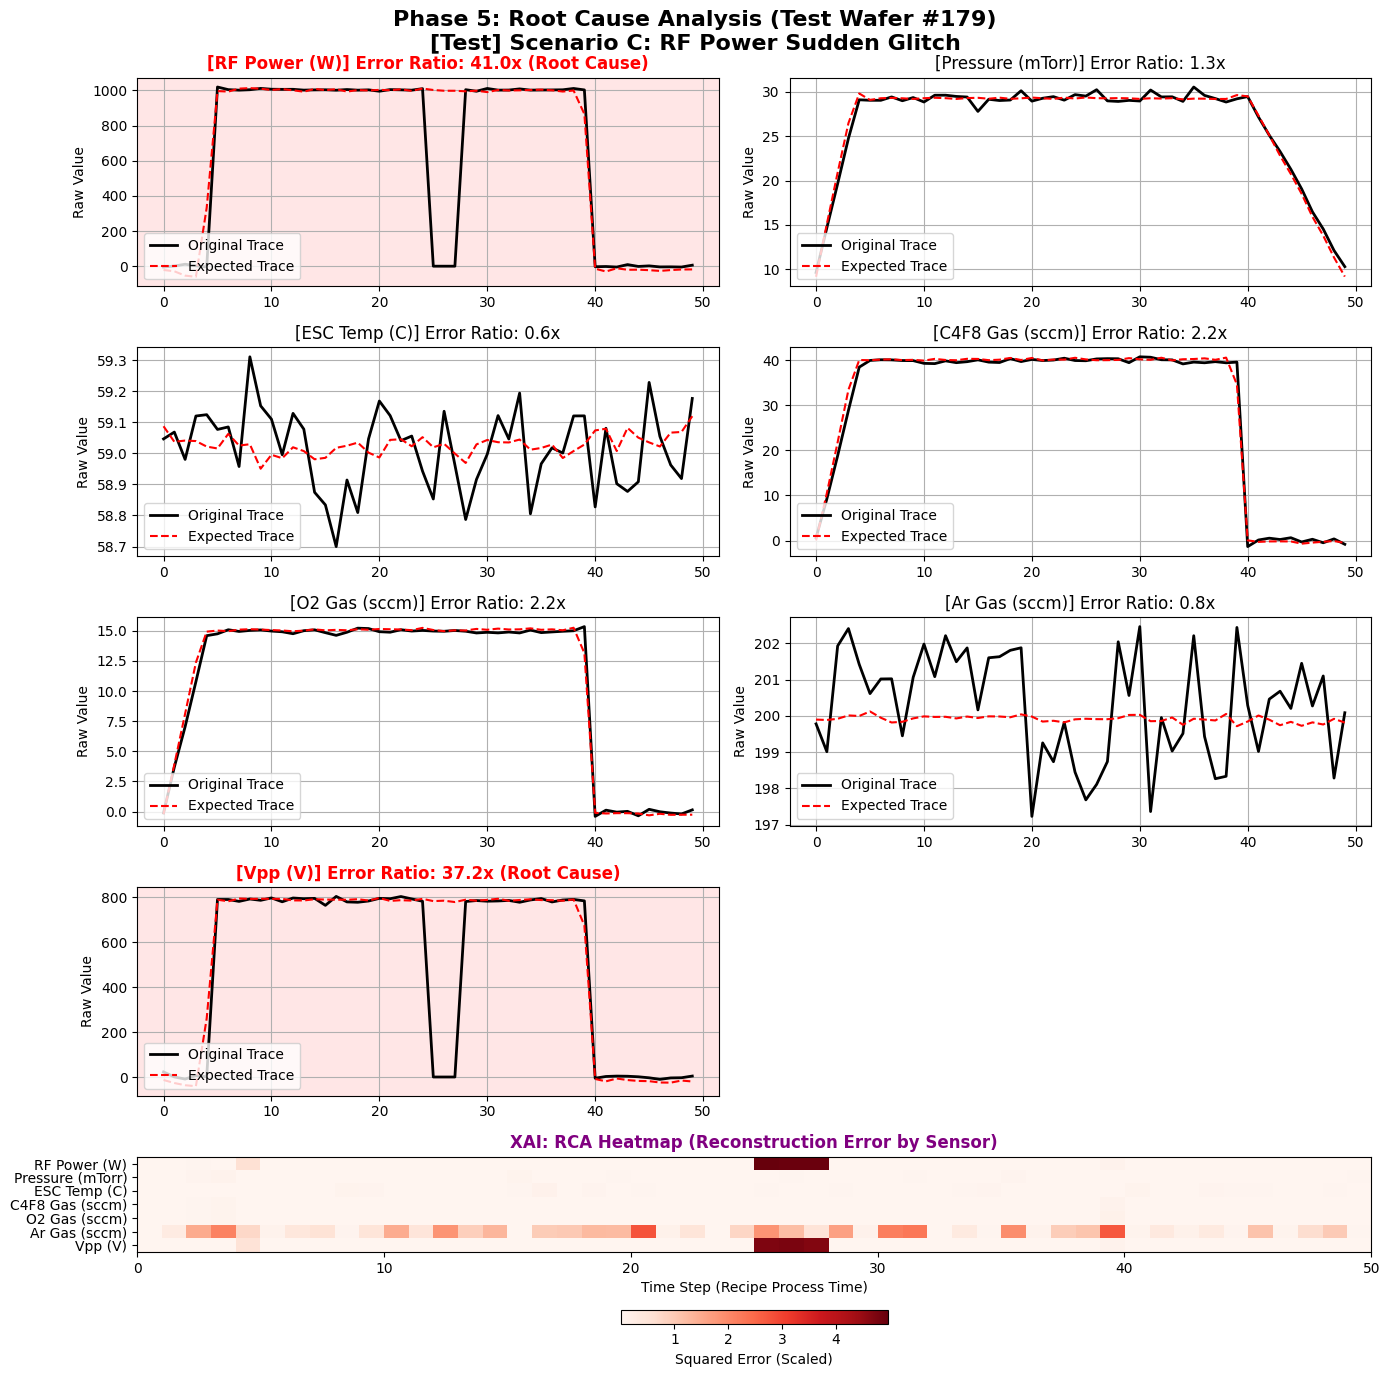


📑 [자동 진단 리포트] Test Wafer #179 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 C: RF Power 순간 글리치
🚨 문제 원인 센서: RF Power (W), Vpp (V)
      * RF Power (W): 평소 정상 대비 오차가 41.0배 폭증함
      * Vpp (V): 평소 정상 대비 오차가 37.2배 폭증함

⏱️ 주요 이상 의심 시점 (RCA Heatmap 기반 에러 극대점):
   -> 전체 50 스텝 중 '25번째 스텝' 부근 (메인 식각(플라즈마 On) 구간에서)에서 실제 값과 예측 값의 괴리가 가장 컸습니다.



In [17]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import math
from scipy.interpolate import interp1d
import copy

# 시스템 설정
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[System] Using device: {device}\n")

# [옵션] Few-shot learning 적용 여부 선택 ('apply', 'skip', 'both')
# * 'both' 선택 시 파운데이션 모델 강화 전/후의 이상 탐지 컨트롤 차트를 상하로 비교합니다.
FEW_SHOT_OPTION = 'both'

output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# Phase 1: Data Ingestion & Interpolation Alignment
# ==========================================
print("Phase 1: Loading data from CSV and Applying Interpolation Alignment...")

data_dir = "factory_data"
trace_csv_path = os.path.join(data_dir, 'raw_fdc_trace.csv')
metro_csv_path = os.path.join(data_dir, 'raw_metrology.csv')

if not os.path.exists(trace_csv_path) or not os.path.exists(metro_csv_path):
    raise FileNotFoundError("CSV files not found. Please run generate_sample_csv.py first.")

df_trace = pd.read_csv(trace_csv_path)
df_metrology = pd.read_csv(metro_csv_path)

sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']
NUM_SENSORS = len(sensor_names)
SEQ_LENGTH = 50
FEW_SHOT_SIZE = 20

# 1-1. DataFrame을 웨이퍼 단위로 분할
wafer_ids = df_trace['Wafer_ID'].unique()
NUM_WAFERS = len(wafer_ids)
raw_X_list = []

grouped = df_trace.groupby('Wafer_ID')
for w_id in wafer_ids:
    wafer_data = grouped.get_group(w_id)[sensor_names].values
    raw_X_list.append(wafer_data)

y_data = df_metrology['Etch_Depth_nm'].values

# 시나리오 매핑 (Few-shot 구간 & Test 구간)
scenario_mapping_en = {
    805: "[Few-Shot] Scenario A: C4F8 Gas Hunting",
    810: "[Few-Shot] Scenario B: Pressure Sluggish Ramp-up",
    815: "[Few-Shot] Scenario C: RF Power Sudden Glitch",
    NUM_WAFERS - 3: "[Test] Scenario A: C4F8 Gas Hunting",
    NUM_WAFERS - 2: "[Test] Scenario B: Pressure Sluggish Ramp-up",
    NUM_WAFERS - 1: "[Test] Scenario C: RF Power Sudden Glitch"
}
scenario_mapping_ko = {
    805: "[Few-Shot] 시나리오 A: C4F8 Gas 유량 헌팅",
    810: "[Few-Shot] 시나리오 B: Pressure 초기 도달 지연",
    815: "[Few-Shot] 시나리오 C: RF Power 순간 글리치",
    NUM_WAFERS - 3: "[Test] 시나리오 A: C4F8 Gas 유량 헌팅",
    NUM_WAFERS - 2: "[Test] 시나리오 B: Pressure 초기 도달 지연",
    NUM_WAFERS - 1: "[Test] 시나리오 C: RF Power 순간 글리치"
}

# 1-2. 1D 선형 보간(Linear Interpolation) 동기화
print(f"-> Resampling all variable-length traces to target length ({SEQ_LENGTH} steps)...")
X_aligned = []
for w in raw_X_list:
    orig_len = len(w)
    x_orig = np.linspace(0, 1, orig_len)
    x_target = np.linspace(0, 1, SEQ_LENGTH)
    f = interp1d(x_orig, w, axis=0, kind='linear')
    X_aligned.append(f(x_target))

X_data = np.array(X_aligned)

# ==========================================
# 이상 시나리오 명시적 주입 (Few-shot 강화 학습을 위해 Few-shot 구간에도 불량 주입)
# ==========================================
r_step1 = int(SEQ_LENGTH * 0.1)
r_step2 = int(SEQ_LENGTH * 0.8)

def inject_anomalies(X, y, idx_a, idx_b, idx_c):
    # 시나리오 A
    hunting_wave = 20 * np.sin(np.linspace(0, 15 * np.pi, r_step2 - r_step1))
    X[idx_a, r_step1:r_step2, 3] += hunting_wave
    y[idx_a] -= 25 # 나쁜 계측치
    # 시나리오 B
    slow_ramp_end = int(SEQ_LENGTH * 0.6)
    sluggish_curve = np.linspace(10, 30, slow_ramp_end)
    X[idx_b, 0:slow_ramp_end, 1] = sluggish_curve + np.random.randn(slow_ramp_end) * 0.5
    y[idx_b] -= 25
    # 시나리오 C
    glitch_idx = int(SEQ_LENGTH * 0.5)
    X[idx_c, glitch_idx:glitch_idx+3, 0] = 0
    X[idx_c, glitch_idx:glitch_idx+3, 6] = 0
    y[idx_c] -= 25

# Few-shot 구간 (800~819) 내 이상 주입
inject_anomalies(X_data, y_data, 805, 810, 815)
# Test 구간 마지막 이상 주입
inject_anomalies(X_data, y_data, NUM_WAFERS-3, NUM_WAFERS-2, NUM_WAFERS-1)

# 1-3. 데이터 스플릿
X_pretrain = X_data[:800]
X_fewshot = X_data[800:800+FEW_SHOT_SIZE]
y_fewshot = y_data[800:800+FEW_SHOT_SIZE]
X_test = X_data[800+FEW_SHOT_SIZE:]
y_test = y_data[800+FEW_SHOT_SIZE:]

# 계측치(y)를 기반으로 불량 여부(Boolean) 라벨 생성 (140~160 범위를 벗어나면 불량)
is_anomaly_fewshot = (y_fewshot < 140) | (y_fewshot > 160)

# 1-4. 정규화
scaler = StandardScaler()
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

# DataLoader 생성 (Few-shot 로더에 이진 라벨 포함)
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=64, shuffle=True)
fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.BoolTensor(is_anomaly_fewshot)), batch_size=4, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled)), batch_size=32, shuffle=False)

print(f"Data ready! Pre-train: {len(X_pretrain)}, Few-shot: {len(X_fewshot)} (Anomalies: {is_anomaly_fewshot.sum()}), Test: {len(X_test)}\n")

# ==========================================
# Models Architecture (Standard Transformer Autoencoder)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_output, attn_weights = self.self_attn(x, x, x)
        x = self.norm1(x + attn_output)
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights

class FDCEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(FDCEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([CustomTransformerLayer(d_model, nhead) for _ in range(num_layers)])
        self.fc_latent = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        for layer in self.layers:
            x, attn_weights = layer(x)

        x_mean = x.mean(dim=1)
        latent = self.fc_latent(x_mean)
        return latent, attn_weights

class FDCDecoder(nn.Module):
    def __init__(self, latent_dim, d_model=64, nhead=4, num_layers=2, output_dim=7, seq_len=50):
        super(FDCDecoder, self).__init__()
        self.seq_len = seq_len
        self.latent_proj = nn.Linear(latent_dim, d_model * self.seq_len)
        self.pos_encoder = PositionalEncoding(d_model)
        decoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layers, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, latent):
        batch_size = latent.size(0)
        x = self.latent_proj(latent).view(batch_size, self.seq_len, -1)
        x = self.pos_encoder(x)
        x = self.transformer_decoder(x)
        reconstruction = self.fc_out(x)
        return reconstruction

class FDCFoundationModel(nn.Module):
    def __init__(self, input_dim=NUM_SENSORS, d_model=64, latent_dim=16, seq_len=50):
        super(FDCFoundationModel, self).__init__()
        self.encoder = FDCEncoder(input_dim, d_model=d_model, latent_dim=latent_dim)
        self.decoder = FDCDecoder(latent_dim, d_model=d_model, output_dim=input_dim, seq_len=seq_len)

    def forward(self, x):
        latent, attn_weights = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, attn_weights


# ==========================================
# Phase 2: Foundation Model Training (Unsupervised)
# ==========================================
print("Phase 2: Foundation Model Pre-training (Unsupervised)...")
foundation_model = FDCFoundationModel(input_dim=NUM_SENSORS, seq_len=SEQ_LENGTH).to(device)
criterion_reconstruction = nn.MSELoss()
optimizer_pretrain = optim.Adam(foundation_model.parameters(), lr=0.001)

MODEL_SAVE_PATH = os.path.join(data_dir, 'foundation_model_aligned.pth')

if os.path.exists(MODEL_SAVE_PATH):
    print(f"-> Found existing model weights: {MODEL_SAVE_PATH}")
    foundation_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
else:
    print("-> Training new Foundation Model...")
    EPOCHS_PRETRAIN = 30
    for epoch in range(EPOCHS_PRETRAIN):
        foundation_model.train()
        total_loss = 0
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(device)
            optimizer_pretrain.zero_grad()
            reconstruction, _ = foundation_model(batch_x)
            loss = criterion_reconstruction(reconstruction, batch_x)
            loss.backward()
            optimizer_pretrain.step()
            total_loss += loss.item()

        if (epoch+1) % 10 == 0:
            print(f"Pre-train Epoch [{epoch+1}/{EPOCHS_PRETRAIN}], Loss: {total_loss/len(train_loader):.4f}")
    torch.save(foundation_model.state_dict(), MODEL_SAVE_PATH)
    print("-> Model training completed and saved.\n")


# ==========================================
# 이상 탐지 평가 전용 헬퍼 함수
# ==========================================
def evaluate_anomalies(model, diag_head=None):
    """
    diag_head(진단 헤드)가 주어지면 딥러닝 스코어로, 없으면 기존의 단순 비율(Baseline)로 이상 탐지 수행
    """
    model.eval()
    if diag_head is not None:
        diag_head.eval()

    train_errors_per_sensor = []
    with torch.no_grad():
        for (batch_x,) in train_loader:
            batch_x_dev = batch_x.to(device)
            recon, _ = model(batch_x_dev)
            mse_sensor = torch.mean((recon.cpu() - batch_x)**2, dim=1).numpy()
            train_errors_per_sensor.extend(mse_sensor)

    normal_sensor_mses = np.mean(train_errors_per_sensor, axis=0)

    train_health_indices = []
    for mse_sensor in train_errors_per_sensor:
        if diag_head is not None:
            norm_mse = torch.FloatTensor(mse_sensor / normal_sensor_mses).unsqueeze(0).to(device)
            with torch.no_grad():
                h_idx = diag_head(norm_mse).item()
        else:
            h_idx = np.max(mse_sensor / normal_sensor_mses)
        train_health_indices.append(h_idx)

    ucl_history = list(train_health_indices[-50:])

    dynamic_ucl, test_health_indices, outliers = [], [], []
    sample_original, sample_reconstructed = None, None

    with torch.no_grad():
        for i, (batch_x,) in enumerate(test_loader):
            batch_x_dev = batch_x.to(device)
            reconstruction, _ = model(batch_x_dev)
            reconstruction = reconstruction.cpu()
            batch_mse_sensor = torch.mean((reconstruction - batch_x)**2, dim=1).numpy()

            for idx_in_batch, mse_sensor in enumerate(batch_mse_sensor):
                if diag_head is not None:
                    norm_mse = torch.FloatTensor(mse_sensor / normal_sensor_mses).unsqueeze(0).to(device)
                    health_idx_val = diag_head(norm_mse).item()
                else:
                    health_idx_val = np.max(mse_sensor / normal_sensor_mses)

                current_mean = np.mean(ucl_history)
                current_std = np.std(ucl_history)
                current_ucl = max(current_mean + 6 * current_std, 2.0)
                dynamic_ucl.append(current_ucl)

                if health_idx_val > current_ucl:
                    outliers.append(len(test_health_indices))
                else:
                    ucl_history.append(health_idx_val)
                    ucl_history.pop(0)
                test_health_indices.append(health_idx_val)

                if sample_original is None and i == 0 and idx_in_batch == 0:
                    sample_original = batch_x[0].numpy()
                    sample_reconstructed = reconstruction[0].numpy()

    return test_health_indices, dynamic_ucl, outliers, normal_sensor_mses, sample_original, sample_reconstructed


# ==========================================
# Phase 3: Diagnostic Head 강화 (Foundation Model은 동결!)
# ==========================================
print("Phase 3: Enhancing Anomaly Detection via Few-Shot Labels...")

class FDCDiagnosticHead(nn.Module):
    def __init__(self, num_sensors):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_sensors, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Softplus() # Health Index는 음수가 될 수 없으므로 Softplus 적용
        )
    def forward(self, sensor_mses):
        return self.net(sensor_mses).squeeze(-1)

diagnostic_head = FDCDiagnosticHead(NUM_SENSORS).to(device)

if FEW_SHOT_OPTION in ['skip', 'both']:
    print("-> [Before Few-Shot] Evaluating Baseline Anomaly Indices...")
    hlth_before, ucl_before, outliers_before, norm_mses_before, orig_b, recon_b = evaluate_anomalies(foundation_model, diag_head=None)

if FEW_SHOT_OPTION in ['apply', 'both']:
    print("-> [Fix] Freezing Autoencoder to preserve 'Expected Trace'...")
    for param in foundation_model.parameters():
        param.requires_grad = False

    print("-> Training Diagnostic Head (Neural Network for Anomaly Scoring)...")
    optimizer_head = optim.Adam(diagnostic_head.parameters(), lr=0.01)
    criterion_head = nn.MSELoss()

    foundation_model.eval()

    temp_mses = []
    with torch.no_grad():
        for (bx,) in train_loader:
            r, _ = foundation_model(bx.to(device))
            temp_mses.extend(torch.mean((r.cpu() - bx)**2, dim=1).numpy())
    norm_mses_tensor = torch.FloatTensor(np.mean(temp_mses, axis=0)).to(device)

    for epoch in range(100):
        diagnostic_head.train()
        for batch_x, batch_is_anomaly in fewshot_loader:
            batch_x = batch_x.to(device)
            batch_is_anomaly = batch_is_anomaly.to(device)
            optimizer_head.zero_grad()

            with torch.no_grad():
                recon, _ = foundation_model(batch_x)
                mse_per_sensor = torch.mean((recon - batch_x)**2, dim=1)
                normalized_mse = mse_per_sensor / norm_mses_tensor

            target_score = torch.where(batch_is_anomaly, torch.tensor(15.0).to(device), torch.tensor(1.0).to(device))

            pred_score = diagnostic_head(normalized_mse)
            loss = criterion_head(pred_score, target_score)

            loss.backward()
            optimizer_head.step()

    print("-> Diagnostic Head Training completed.\n")

    print("-> [After Few-Shot] Evaluating Enhanced Anomaly Indices...")
    hlth_after, ucl_after, outliers_after, norm_mses_after, orig_a, recon_a = evaluate_anomalies(foundation_model, diag_head=diagnostic_head)
else:
    print("-> Skipping Few-Shot Fine-tuning.\n")

if FEW_SHOT_OPTION == 'both':
    print("\n" + "="*65)
    print("📊 [Few-Shot 성능 강화 비교: 이상 탐지 능력 변화 리포트]")
    print(f" - 강화 전 이상 웨이퍼 탐지수 : {len(outliers_before)}건")
    print(f" - 강화 후 이상 웨이퍼 탐지수 : {len(outliers_after)}건")
    print("="*65 + "\n")

final_outliers = outliers_after if FEW_SHOT_OPTION in ['apply', 'both'] else outliers_before
final_health = hlth_after if FEW_SHOT_OPTION in ['apply', 'both'] else hlth_before
final_ucl = ucl_after if FEW_SHOT_OPTION in ['apply', 'both'] else ucl_before
sample_original = orig_a if FEW_SHOT_OPTION in ['apply', 'both'] else orig_b
sample_reconstructed = recon_a if FEW_SHOT_OPTION in ['apply', 'both'] else recon_b
normal_sensor_mses = norm_mses_after if FEW_SHOT_OPTION in ['apply', 'both'] else norm_mses_before

# ==========================================
# [추가] 100점 만점 Health Score 변환
# ==========================================
# UCL 한계선을 '60점'으로 기준을 잡아 매핑 (최대 90점, 최소 45점)
# Health Score = 90 - (현재 Health Index / 현재 UCL) * 30
final_health_arr = np.array(final_health)
final_ucl_arr = np.array(final_ucl)
final_scores_100 = np.clip(90 - (final_health_arr / final_ucl_arr) * 30, 45, 90)

# ==========================================
# Phase 4: Final Visualization (Control Charts & Score)
# ==========================================
print("Phase 4: Plotting Anomaly Detection Control Charts...")

# 차트 레이아웃 구성: 스코어 차트를 추가하기 위해 행(row)을 늘림
if FEW_SHOT_OPTION == 'both':
    fig = plt.figure(figsize=(18, 18)) # 4 rows
    gs = gridspec.GridSpec(4, 3, figure=fig)
else:
    fig = plt.figure(figsize=(18, 14)) # 3 rows
    gs = gridspec.GridSpec(3, 3, figure=fig)

# 1. 상단: 샘플 데이터 복원 퀄리티
rep_sensor_indices = [0, 1, 6]
for plot_idx, sensor_idx in enumerate(rep_sensor_indices):
    ax = fig.add_subplot(gs[0, plot_idx])
    ax.plot(sample_original[:, sensor_idx], label=f'Original ({sensor_names[sensor_idx]})', color='black', linewidth=2)
    ax.plot(sample_reconstructed[:, sensor_idx], label='Recon', color='red', linestyle='--')
    ax.set_title(f'FDC Trace Reconstruction: {sensor_names[sensor_idx]}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='lower left')
    ax.grid(True)

# 2. 중단: Few-shot 강화 전/후 Health Index 차트
if FEW_SHOT_OPTION == 'both':
    ax_before = fig.add_subplot(gs[1, :])
    ax_before.scatter(range(len(hlth_before)), hlth_before, color='gray', s=20, alpha=0.7, label='Health Index')
    ax_before.plot(range(len(ucl_before)), ucl_before, color='red', linestyle='--', linewidth=2, label='Dynamic UCL')
    if len(outliers_before) > 0:
        ax_before.scatter(outliers_before, np.array(hlth_before)[outliers_before], color='orange', s=60, edgecolors='black', label='Anomaly Detected')
    ax_before.set_title('BEFORE Few-Shot: Baseline Autoencoder (Max Error Ratio)', fontweight='bold')
    ax_before.set_ylabel('Health Index (Raw)')
    ax_before.legend(loc='upper left')
    ax_before.grid(True)

    ax_after = fig.add_subplot(gs[2, :])
    ax_after.scatter(range(len(hlth_after)), hlth_after, color='teal', s=20, alpha=0.8, label='Health Index')
    ax_after.plot(range(len(ucl_after)), ucl_after, color='red', linestyle='--', linewidth=2, label='Dynamic UCL')
    if len(outliers_after) > 0:
        ax_after.scatter(outliers_after, np.array(hlth_after)[outliers_after], color='red', s=60, edgecolors='black', label='Anomaly Detected (Enhanced)')
    ax_after.set_title('AFTER Few-Shot: Diagnostic Head Applied (Max Error Ratio)', fontweight='bold', color='darkred')
    ax_after.set_ylabel('Health Index (Raw)')
    ax_after.legend(loc='upper left')
    ax_after.grid(True)
else:
    ax_single = fig.add_subplot(gs[1, :])
    ax_single.scatter(range(len(final_health)), final_health, color='teal', s=20, alpha=0.8, label='Health Index')
    ax_single.plot(range(len(final_ucl)), final_ucl, color='red', linestyle='--', linewidth=2, label='Dynamic UCL')
    if len(final_outliers) > 0:
        ax_single.scatter(final_outliers, np.array(final_health)[final_outliers], color='red', s=60, edgecolors='black', label='Anomaly Detected')
    ax_single.set_title(f'FDC Equipment Health Control Chart (Option: {FEW_SHOT_OPTION})', fontweight='bold')
    ax_single.set_ylabel('Health Index (Raw)')
    ax_single.legend(loc='upper left')
    ax_single.grid(True)

# 3. 하단 [추가]: 현업 엔지니어를 위한 100점 만점 환산 스코어 차트
if FEW_SHOT_OPTION == 'both':
    ax_score = fig.add_subplot(gs[3, :])
else:
    ax_score = fig.add_subplot(gs[2, :])

ax_score.scatter(range(len(final_scores_100)), final_scores_100, color='forestgreen', s=25, alpha=0.8, label='Wafer Score (Points)')
ax_score.axhline(y=60, color='red', linestyle='--', linewidth=2, label='Warning Threshold (60 pts)')

# 60점 미만의 위험 구역 붉은색 배경 처리
ax_score.fill_between(range(len(final_scores_100)), 40, 60, color='red', alpha=0.05)

if len(final_outliers) > 0:
    ax_score.scatter(final_outliers, final_scores_100[final_outliers], color='red', s=70, edgecolors='black', label='Fail / Anomaly')

ax_score.set_title('Final Wafer Health Score (Scale: 45-90, Warning at 60)', fontweight='bold', color='darkgreen')
ax_score.set_xlabel('Test Wafer Index (Time Order)')
ax_score.set_ylabel('Equipment Score (45-90)')
ax_score.set_ylim(40, 95)
ax_score.legend(loc='lower left')
ax_score.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 진단 결과 CSV 저장 (100점 환산 스코어 추가)
# ==========================================
test_start_idx = 800 + FEW_SHOT_SIZE
df_dict = {
    'Original_Wafer_ID': range(test_start_idx, test_start_idx + len(y_test)),
}
if FEW_SHOT_OPTION in ['skip', 'both']:
    df_dict['Health_Index_Before'] = hlth_before
    df_dict['Is_Anomaly_Before'] = [True if i in outliers_before else False for i in range(len(y_test))]
if FEW_SHOT_OPTION in ['apply', 'both']:
    df_dict['Health_Index_After'] = hlth_after
    df_dict['Is_Anomaly_After'] = [True if i in final_outliers else False for i in range(len(y_test))]

# 최종 100점 스코어 컬럼 추가
df_dict['Final_Health_Score_100'] = np.round(final_scores_100, 1)

df_test_results = pd.DataFrame(df_dict)
results_csv_path = os.path.join(output_dir, '05_phase4_fdc_test_results.csv')
df_test_results.to_csv(results_csv_path, index=False)
print(f"-> 100점 환산 스코어가 포함된 진단 결과 CSV 저장 완료: {results_csv_path}\n")


# ==========================================
# Phase 5: XAI & Root Cause Analysis
# ==========================================
print("Phase 5: XAI Root Cause Analysis")

if len(final_outliers) > 0:
    for anomaly_idx in final_outliers:
        original_wafer_id = test_start_idx + anomaly_idx
        scenario_desc_en = scenario_mapping_en.get(original_wafer_id, "Unknown General Drift")
        scenario_desc_ko = scenario_mapping_ko.get(original_wafer_id, "알 수 없는 일반적 이상(General Drift)")

        anomaly_tensor = torch.FloatTensor(X_test_scaled[anomaly_idx]).unsqueeze(0)

        # Autoencoder는 동결되었으므로 Before/After 상관없이 동일하고 정확한 복원 파형을 제공합니다.
        foundation_model.eval()

        with torch.no_grad():
            anomaly_recon, _ = foundation_model(anomaly_tensor.to(device))
            anomaly_recon = anomaly_recon.cpu()

        anomaly_original_np = anomaly_tensor.squeeze(0).numpy()
        anomaly_recon_np = anomaly_recon.squeeze(0).numpy()

        anomaly_sensor_mses = np.mean((anomaly_original_np - anomaly_recon_np)**2, axis=0)
        error_ratio = anomaly_sensor_mses / normal_sensor_mses
        ratio_threshold = np.mean(error_ratio) + 0.5 * np.std(error_ratio)

        raw_anomaly_original_np = scaler.inverse_transform(anomaly_original_np)
        raw_anomaly_recon_np = scaler.inverse_transform(anomaly_recon_np)

        fig = plt.figure(figsize=(14, 14))
        fig.suptitle(f'Phase 5: Root Cause Analysis (Test Wafer #{anomaly_idx})\n{scenario_desc_en}', fontsize=16, fontweight='bold')
        # 하단 Heatmap 영역 비율을 조금 더 늘려 전체 센서가 잘 보이도록 수정 (0.5 -> 0.8)
        gs = gridspec.GridSpec(5, 2, figure=fig, height_ratios=[1, 1, 1, 1, 0.8])

        axs = []
        for i in range(4):
            for j in range(2):
                if i * 2 + j < NUM_SENSORS:
                    axs.append(fig.add_subplot(gs[i, j]))

        for i in range(NUM_SENSORS):
            axs[i].plot(raw_anomaly_original_np[:, i], label='Original Trace', color='black', linewidth=2)
            axs[i].plot(raw_anomaly_recon_np[:, i], label='Expected Trace', color='red', linestyle='--')

            is_root_cause = error_ratio[i] > ratio_threshold
            title_text = f'[{sensor_names[i]}] Error Ratio: {error_ratio[i]:.1f}x'

            if is_root_cause:
                title_text += ' (Root Cause)'
                axs[i].set_facecolor('#ffe6e6')
                axs[i].set_title(title_text, color='red', fontweight='bold')
            else:
                axs[i].set_title(title_text, color='black')

            axs[i].set_ylabel('Raw Value')
            axs[i].legend(loc='lower left')
            axs[i].grid(True)

        ax_attn = fig.add_subplot(gs[4, :])

        # [수정] Attention 대신 실제 복원 오차(MSE)를 수치화한 RCA Heatmap(2D) 생성
        # Original과 Recon 간의 오차를 기반으로 어떤 센서가 어느 시점에서 크게 튀었는지 확인
        rca_error_matrix = ((anomaly_original_np - anomaly_recon_np)**2).T # (NUM_SENSORS, SEQ_LENGTH)

        im = ax_attn.imshow(rca_error_matrix, cmap='Reds', aspect='auto', extent=[0, SEQ_LENGTH, NUM_SENSORS, 0])
        ax_attn.set_title('XAI: RCA Heatmap (Reconstruction Error by Sensor)', fontweight='bold', color='purple')
        ax_attn.set_xlabel('Time Step (Recipe Process Time)')

        # Y축에 센서 이름 표시
        ax_attn.set_yticks(np.arange(NUM_SENSORS) + 0.5)
        ax_attn.set_yticklabels(sensor_names)

        fig.colorbar(im, ax=ax_attn, orientation='horizontal', fraction=0.08, pad=0.35, label='Squared Error (Scaled)')
        plt.tight_layout()
        plt.show()

        # 콘솔 출력 (한국어 리포트)
        root_cause_sensors = [sensor_names[i] for i in range(NUM_SENSORS) if error_ratio[i] > ratio_threshold]

        # [수정] 어텐션 대신, 전체 센서의 오차 합이 가장 컸던 시점을 주요 의심 시점으로 도출
        critical_step = np.argmax(np.sum(rca_error_matrix, axis=0))

        print(f"\n" + "="*70)
        print(f"📑 [자동 진단 리포트] Test Wafer #{anomaly_idx} 불량 분석 요약")
        print(f"   ▶ 인지된 시나리오 타입: {scenario_desc_ko}")
        print(f"="*70)

        if root_cause_sensors:
            print(f"🚨 문제 원인 센서: {', '.join(root_cause_sensors)}")
            for rc_sensor in root_cause_sensors:
                idx = sensor_names.index(rc_sensor)
                print(f"      * {rc_sensor}: 평소 정상 대비 오차가 {error_ratio[idx]:.1f}배 폭증함")
        else:
            print(f"🚨 문제 원인: 단일 센서의 급격한 이상보다는 전체적인 파형 밸런스가 미세하게 무너졌습니다.")

        step_desc = "레시피 진행 중"
        if critical_step < int(SEQ_LENGTH * 0.1): step_desc = "가스 안정화(초기 램프업) 구간에서"
        elif critical_step > int(SEQ_LENGTH * 0.8): step_desc = "퍼지 및 오버에치 구간에서"
        else: step_desc = "메인 식각(플라즈마 On) 구간에서"

        print(f"\n⏱️ 주요 이상 의심 시점 (RCA Heatmap 기반 에러 극대점):")
        print(f"   -> 전체 {SEQ_LENGTH} 스텝 중 '{critical_step}번째 스텝' 부근 ({step_desc})에서 실제 값과 예측 값의 괴리가 가장 컸습니다.")
        print(f"="*70 + "\n")
else:
    print("UCL을 초과하는 이상 웨이퍼가 발견되지 않아 Deep Dive를 생략합니다.")